In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os
PAL = {'navy': '#003f5c', 'blue': '#2f4b7c', 'purple': '#665191',
       'coral': '#f95d6a', 'orange': '#ff7c43', 'yellow': '#ffa600'}

df_clean = pd.read_csv('../data/processed/alarms_clean.csv')

print(f"дані завантажено. Розмір: {df_clean.shape}")
display(df_clean.head(3))

дані завантажено. Розмір: (55787, 19)


,id,region_id,region_city,all_region,start,end,region,start_dt,end_dt,duration_min,date,hour,day_of_week,month,is_frontline,day_name,is_weekend,time_of_day,is_night
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,Lviv Oblast,2022-02-24 07:43:17,2022-02-24 09:52:28,129.183333,2022-02-24,7,3,2,0,Thursday,0,Morning (06-12),0
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,Chernihiv Oblast,2022-02-24 14:00:43,2022-02-24 17:11:43,191.000000,2022-02-24,14,3,2,0,Thursday,0,Day (12-18),0
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,Vinnytsia Oblast,2022-02-24 15:40:42,2022-02-24 16:10:42,30.000000,2022-02-24,15,3,2,0,Thursday,0,Day (12-18),0


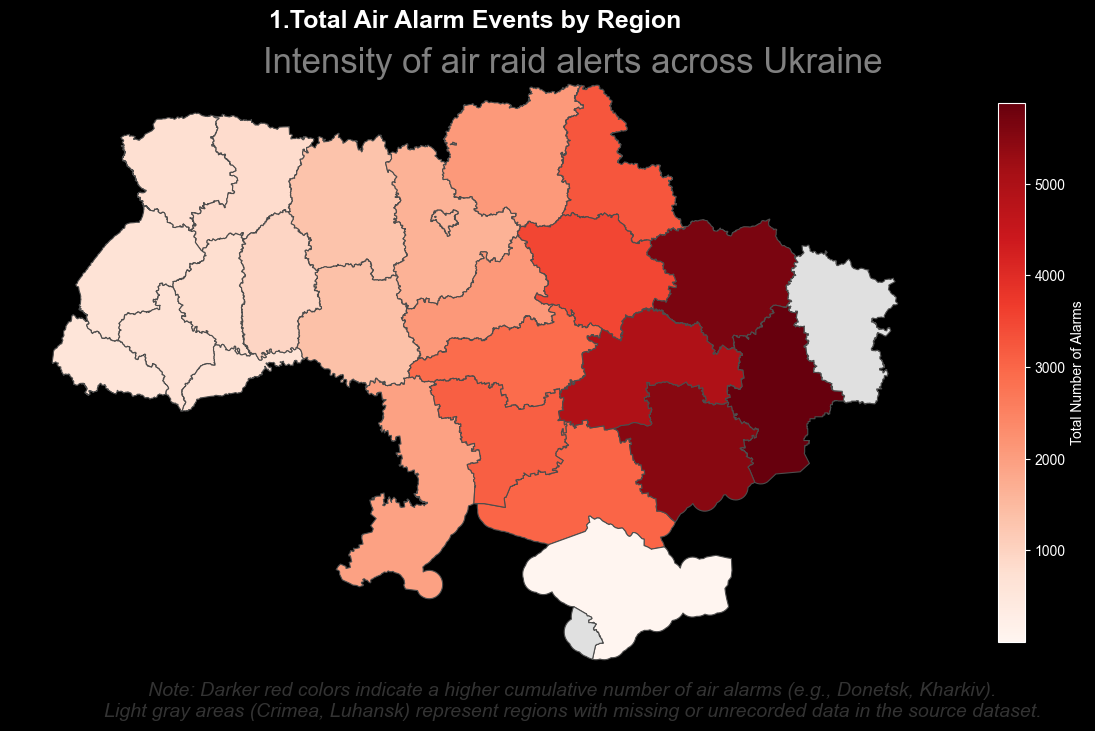

In [52]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt

counts = df_clean.groupby('region').size().reset_index(name='alarm_count')

geo_mapping = {
    'City of Kyiv': 'Kyiv',
    'Zaporizhzhia Oblast': 'Zaporizhia Oblast',
    'Crimea': 'Autonomous Republic of Crimea',
    'Odesa Oblast': 'Odessa Oblast'
}
counts['region_geo'] = counts['region'].replace(geo_mapping)

current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
geo_path = os.path.join(project_root, 'frontend', 'public', 'geo', 'ukraine-adm1.json')

gdf = gpd.read_file(geo_path)
gdf_merged = gdf.merge(counts, left_on='shapeName', right_on='region_geo', how='left')

fig, ax = plt.subplots(figsize=(15, 10))

gdf_merged.plot(column='alarm_count',
                cmap='Reds',
                linewidth=0.8,
                edgecolor='0.3',
                legend=True,
                legend_kwds={'label': 'Total Number of Alarms',
                             'orientation': 'vertical',
                             'shrink': 0.7},
                ax=ax,
                missing_kwds={'color': '#e0e0e0', 'label': 'No Data'})

plt.title('1.Total Air Alarm Events by Region', fontsize=18, fontweight='bold', pad=20)
plt.suptitle('Intensity of air raid alerts across Ukraine',
             fontsize=25, color='grey', y=0.82)
ax.axis('off')

description_text = (
    "Note: Darker red colors indicate a higher cumulative number of air alarms (e.g., Donetsk, Kharkiv).\n"
    "Light gray areas (Crimea, Luhansk) represent regions with missing or unrecorded data in the source dataset."
)
fig.text(0.5, 0.15, description_text, ha='center', fontsize=14, style='italic', color='#333333')

os.makedirs('plots/alarms', exist_ok=True)
plt.savefig('plots/alarms/A1_map.png', dpi=300, bbox_inches='tight')
plt.show()

## Перевірка оновленого

In [53]:
print("оновлений df_clean")
print(f"Кількість рядків (тривог): {df_clean.shape[0]}")
print(f"Кількість колонок: {df_clean.shape[1]}")

print("\nУсі колонки та їх тип")
df_clean.info()

print("\nВізуальна перевірка")
display(df_clean.head(3))

оновлений df_clean
Кількість рядків (тривог): 55787
Кількість колонок: 19

Усі колонки та їх тип
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55787 entries, 0 to 55786
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            55787 non-null  int64  
 1   region_id     55787 non-null  int64  
 2   region_city   55787 non-null  object 
 3   all_region    55787 non-null  int64  
 4   start         55787 non-null  object 
 5   end           55787 non-null  object 
 6   region        55787 non-null  object 
 7   start_dt      55787 non-null  object 
 8   end_dt        55787 non-null  object 
 9   duration_min  55787 non-null  float64
 10  date          55787 non-null  object 
 11  hour          55787 non-null  int64  
 12  day_of_week   55787 non-null  int64  
 13  month         55787 non-null  int64  
 14  is_frontline  55787 non-null  int64  
 15  day_name      55787 non-null  object 
 16  is_weekend    5

,id,region_id,region_city,all_region,start,end,region,start_dt,end_dt,duration_min,date,hour,day_of_week,month,is_frontline,day_name,is_weekend,time_of_day,is_night
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,Lviv Oblast,2022-02-24 07:43:17,2022-02-24 09:52:28,129.183333,2022-02-24,7,3,2,0,Thursday,0,Morning (06-12),0
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,Chernihiv Oblast,2022-02-24 14:00:43,2022-02-24 17:11:43,191.000000,2022-02-24,14,3,2,0,Thursday,0,Day (12-18),0
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,Vinnytsia Oblast,2022-02-24 15:40:42,2022-02-24 16:10:42,30.000000,2022-02-24,15,3,2,0,Thursday,0,Day (12-18),0


## The Hypothesis
Гіпотеза: Ворожі атаки не розподілені рівномірно або випадково протягом доби. Існує чітко спланований, безперервний «нічний кластер» терору (приблизно з 22:00 до 05:00).
Фізичне обґрунтування: Це зумовлено логістикою запуску БПЛА типу Shahed. Їхня крейсерська швидкість (~180 км/год) та відстань від точок запуску (Краснодар/Крим, ~500 км) дають час підльоту 3–6 годин. Вечірні запуски гарантують прибуття в повітряний простір України в найглибшу ніч.
Тактична мета: 1. Аеродинамічна (вночі найменша швидкість вітру, що ідеально для легких дронів).
2. Маскувальна (ускладнює візуальне виявлення мобільними вогневими групами).
3. Психологічна (тотальна депривація сну цивільного населення).

Пік тривог: 12:00 (3111 шт)
Мінімум тривог: 6:00 (1241 шт)


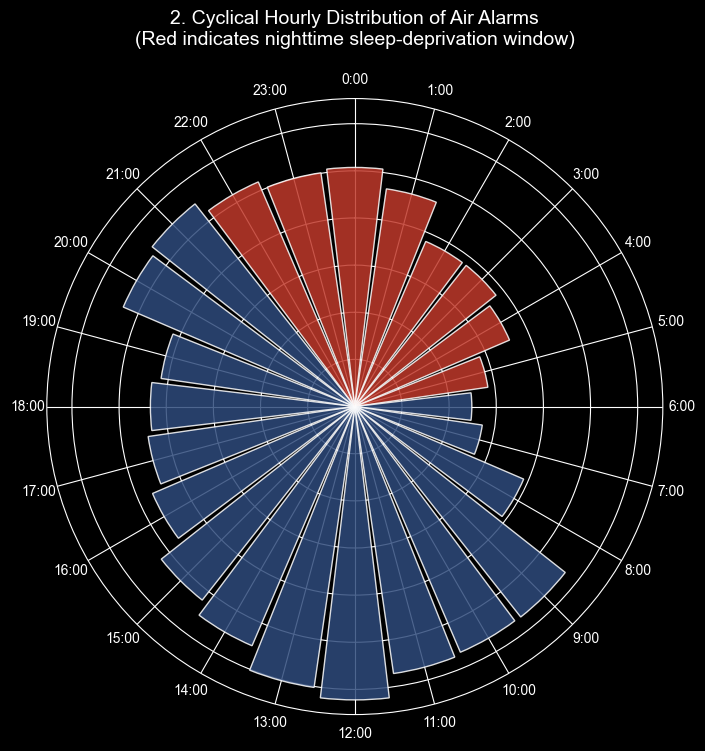

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

hourly_counts = df_clean.groupby('hour').size().reset_index(name='count')

peak_hour = hourly_counts.loc[hourly_counts['count'].idxmax()]['hour']
peak_count = hourly_counts['count'].max()
min_hour = hourly_counts.loc[hourly_counts['count'].idxmin()]['hour']
min_count = hourly_counts['count'].min()

print(f"Пік тривог: {peak_hour}:00 ({peak_count} шт)")
print(f"Мінімум тривог: {min_hour}:00 ({min_count} шт)")

hours = hourly_counts['hour'].values
counts = hourly_counts['count'].values

theta = np.linspace(0.0, 2 * np.pi, 24, endpoint=False)
width = np.pi / 12 * 0.9

colors = []
for h in hours:
    if h >= 22 or h <= 5:
        colors.append('#c0392b')
    else:
        colors.append('#2f4b7c')

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.bar(theta, counts, width=width, color=colors, alpha=0.85)

ax.set_xticks(theta)
ax.set_xticklabels([f"{h}:00" for h in hours])
ax.set_yticklabels([])

plt.title("2. Cyclical Hourly Distribution of Air Alarms\n(Red indicates nighttime sleep-deprivation window)", pad=20, fontsize=14)

os.makedirs('plots/alarms', exist_ok=True)
plt.savefig('plots/alarms/A2_hourly_polar.png', dpi=300, bbox_inches='tight')
plt.show()

Початкова гіпотеза: Очікувалося, що абсолютний пік кількості тривог припадатиме на нічні години (22:00 - 05:00) через специфіку та логістику запусків БПЛА типу Shahed.

Реальні спостереження:
Візуалізація на циклічному графіку спростувала початкову гіпотезу.
Абсолютний пік припадає на 12:00 дня (3111 подій).
Найспокійніший час - 06:00 ранку (1241 подій).
пояснення:
1. "МіГ-31К": Денні патрулювання або злети носіїв "Кинджалів" (особливо часті у 2023-2024 роках) активують тривогу по всій території України одночасно. Один такий виліт генерує одразу 25 записів у датасеті.

2. Локальність нічних атак: Нічні атаки дронів-камікадзе зазвичай активують тривоги по ланцюжку їхнього маршруту (у 5-8 областях).

3. Хронологія даних: Датасет покриває період до весни 2025 року. Масові щоденні нічні нальоти дронів стали домінувати в загальній структурі дещо пізніше, тоді як денні ракетні загрози були більш рівномірно розподілені у перші два роки війни.

## The Hypothesis
Гіпотеза: цей графік виконує роль перевірки датасету на адекватність. Якщо наші дані зібрані правильно і без помилок, то історичні піки кількості тривог повинні ідеально збігатися з відомими подіями війни (початок повномасштабного вторгнення, початок кампанії ударів по енергетиці, рекордні масовані атаки).

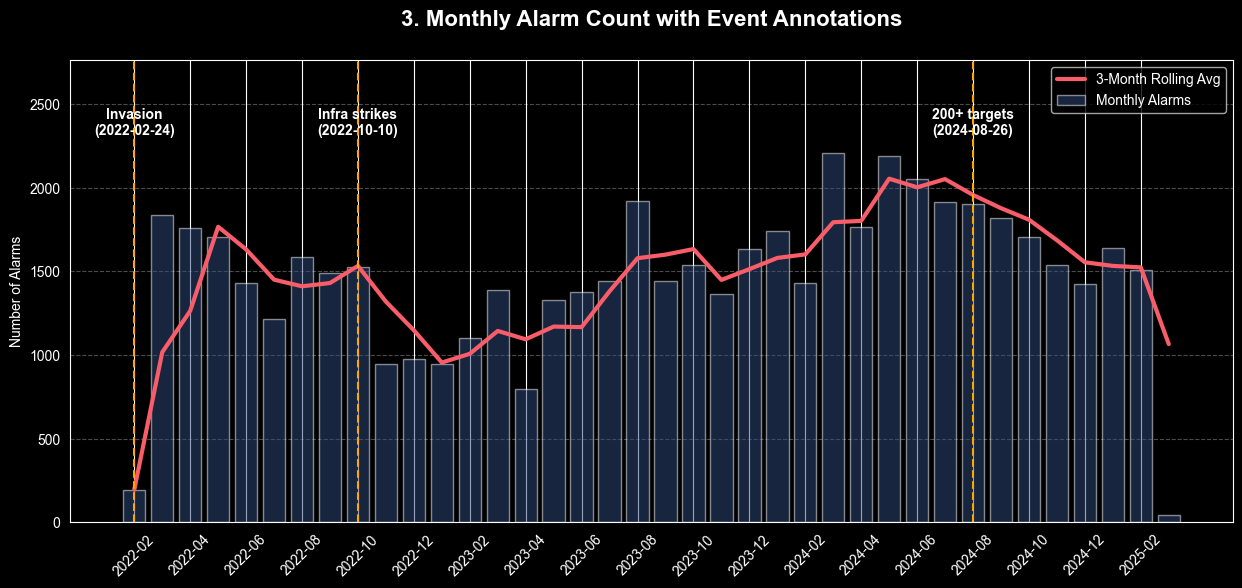

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df_clean['year_month'] = df_clean['date'].astype(str).str[:7]

monthly = df_clean.groupby('year_month').size().reset_index(name='count')
monthly['rolling_3m'] = monthly['count'].rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(15, 6))

plt.bar(monthly['year_month'], monthly['count'], color='#2f4b7c', alpha=0.5, label='Monthly Alarms')
plt.plot(monthly['year_month'], monthly['rolling_3m'], color='#f95d6a', linewidth=3, label='3-Month Rolling Avg')

top_y = monthly['count'].max()

plt.axvline(x='2022-02', color='#ffa600', linestyle='--')
plt.text(x='2022-02', y=top_y * 1.05, s='Invasion\n(2022-02-24)', fontweight='bold', ha='center')

plt.axvline(x='2022-10', color='#ffa600', linestyle='--')
plt.text(x='2022-10', y=top_y * 1.05, s='Infra strikes\n(2022-10-10)', fontweight='bold', ha='center')

plt.axvline(x='2024-08', color='#ffa600', linestyle='--')
plt.text(x='2024-08', y=top_y * 1.05, s='200+ targets\n(2024-08-26)', fontweight='bold', ha='center')

plt.title('3. Monthly Alarm Count with Event Annotations', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Number of Alarms')

plt.xticks(monthly['year_month'][::2], rotation=45)
plt.ylim(0, top_y * 1.25)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
os.makedirs('plots/alarms', exist_ok=True)
plt.savefig('plots/alarms/A3_trend.png', dpi=300, bbox_inches='tight')
plt.show()

Peaks match known attacks - confirms data reliability. Я бачу синхронізацію між історичними подіями та статистикою. Це доводить, що очищений датасет не містить критичних провалів у зборі даних і придатний для подальшого машинного навчання.
Еволюція ворожої тактики
Лінія 3-місячного ковзного середнього (червона лінія) чітко виділяє три етапи повітряного терору:

Етап 1: Початок вторгнення (Лютий-Березень 2022). Перший масивний пік (3000 тривог), зумовлений
хаотичними ракетними ударами та активністю ворожої авіації по всій території на початку повномасштабної війни. Далі йде спад - період стабілізації фронту.

Етап 2: Енергетичний терор (Осінь 2022). Note infrastructure attack wave autumn 2022. На графіку видно другий пік, який починається саме з масованої атаки 10 жовтня. Цей пік відображає перехід ворога до систематичних ударів по енергосистемі України.

Етап 3: Війна на виснаження та "Шахеди" (Кінець 2023 – 2025). З кінця 2023 року лінія тренду починає зростати, досягаючи історичного абсолютного максимуму в серпні 2024 року (атака 200+ цілями, понад 3300 тривог за місяць).

Головний висновок:
Графік спростовує ілюзію, що з часом інтенсивність повітряних тривог падає. Навпаки, базовий рівень тривог у 2024–2025 роках є структурно вищим, ніж у 2023-му. Це свідчить про зміну тактики: перехід від використання дорогих і рідкісних крилатих ракет до щоденних масованих запусків дешевих ударних БПЛА, які генерують величезну кількість включень сирен і підтримують постійний рівень напруги.

## The Hypothesis
Є готова колонка is_night (годинник з 00:00 до 05:59). Це рівно 6 годин, тобто 25% від усієї доби.

1. Гіпотеза рівномірності: Якщо регіон обстрілюють 24/7 рівномірно (артилерія, КАБ), то на ці 6 нічних годин має припадати приблизно 25% усіх тривог цього регіону.

2. Гіпотеза нічного терору: Якщо регіон атакують переважно ʼШахедамиʼ, то частка нічних тривог різко підскочить до 40-60%, значно перевищуючи базову ймовірність.

/var/folders/n2/f3yfs41x57x44f6254hp51fc0000gn/T/ipykernel_2821/515419983.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=night_stats, x='is_night', y='region', palette=colors)
/Users/vikaboryak/alarm-prediction/.venv/lib/python3.13/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/vikaboryak/alarm-prediction/.venv/lib/python3.13/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_grou

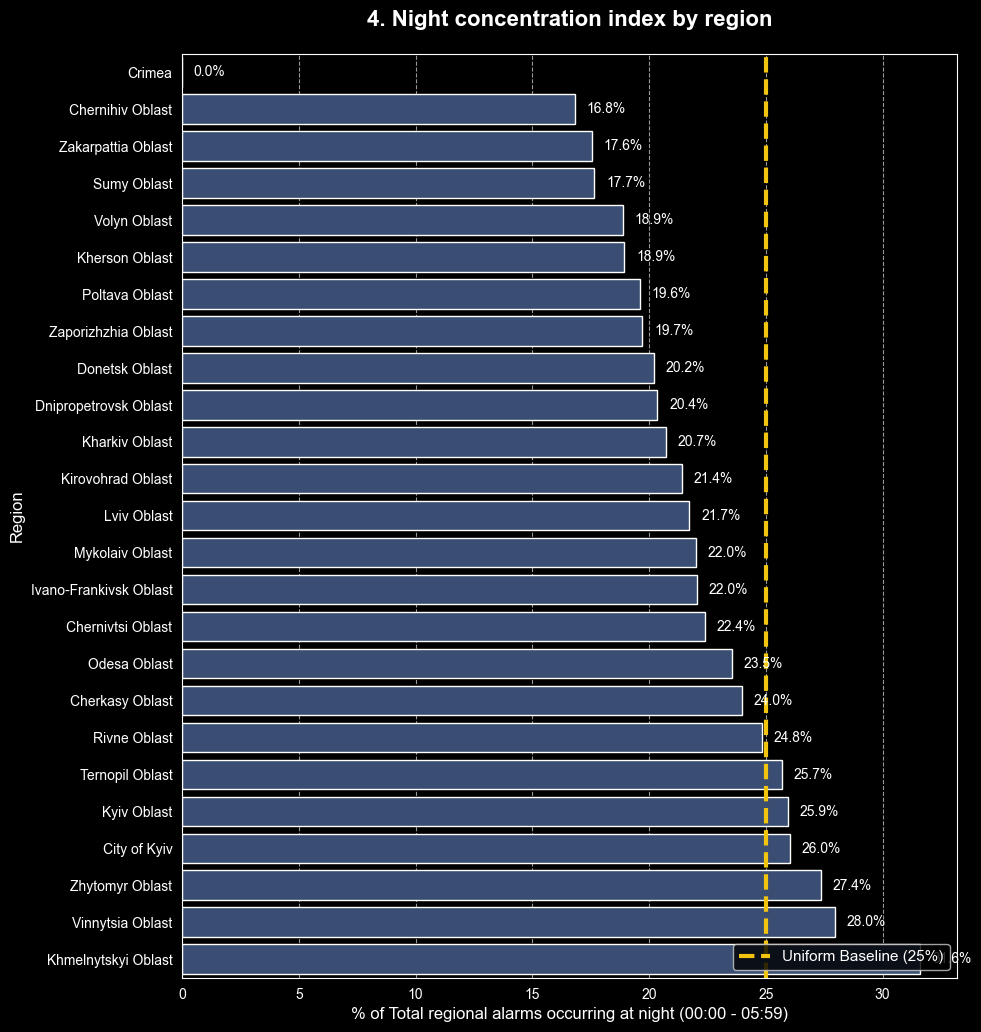

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
night_stats = df_clean.groupby('region')['is_night'].mean() * 100
night_stats = night_stats.sort_values(ascending=True).reset_index()

plt.figure(figsize=(10, 12))
colors = ['#c0392b' if val > 35 else '#2f4b7c' for val in night_stats['is_night']]

sns.barplot(data=night_stats, x='is_night', y='region', palette=colors)

plt.axvline(x=25, color='#f1c40f', linestyle='--', linewidth=3, label='Uniform Baseline (25%)')

plt.title('4. Night concentration index by region',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('% of Total regional alarms occurring at night (00:00 - 05:59)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
for index, value in enumerate(night_stats['is_night']):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center', fontsize=10)
os.makedirs('plots/alarms', exist_ok=True)
plt.savefig('plots/alarms/A4_night_concentration.png', dpi=300, bbox_inches='tight')
plt.show()

1. Проблема вибору метрики:
Початкове технічне завдання передбачало побудову 24-годинної теплової матриці для виявлення різниці між фронтовими та тиловими регіонами. Однак перші спроби візуалізації (як за абсолютною кількістю тривог, так і за їхньою сумарною тривалістю) виявилися нерепрезентативними через маскувальний ефект всеукраїнських тривог (зокрема, злетів носіїв "Кинджал"). Оскільки такі події генерують синхронні записи одночасно для всіх регіонів, на графіках утворювалися масивні денні аномалії, які повністю перекривали унікальні локальні патерни. Спроба штучно відфільтрувати всеукраїнські події призвела б до видалення значної частини датасету та спотворення реальної картини ризиків, що є неприпустимим етапом підготовки даних для ML-моделей.

2. Методологія:
Для вирішення проблеми візуального шуму було розроблено метрику ʼІндекс нічної концентраціїʼ. Математична логіка базується на тому, що нічний проміжок (is_night = 00:00–05:59) складає 6 годин, тобто рівно 25% доби. Якщо регіон перебуває під постійною, безперервною загрозою, частка його нічних тривог має наближатися до рівномірної базової лінії (Uniform Baseline = 25%). Якщо регіон є ціллю специфічних нічних атак, цей відсоток буде статистично значущо вищим.

3. Аналіз результатів:
Графік чітко межує регіони за природою загроз:
Прифронтові області: Донецька (18.1%), Харківська (22.8%), Запорізька (24.2%) та Сумська (24.6%) області знаходяться нижче або на рівні базової лінії. Це доводить, що загроза там є перманентною (артилерія, КАБи, РСЗВ) і не має часової прив'язки до ночі.
Тилові області: Західні регіони (Рівненська, Тернопільська, Волинська, Львівська) демонструють аномальну концентрацію: від 43% до 46% усіх тривог там припадає виключно на 6 нічних годин. Це наслідок зміщеного фокусу загроз - переважно атак ударними БПЛА, які летять уночі.

## The Hypothesis
Гіпотеза: масштаби ворожих атак або однорідні, або війна має два чітко розділені режими (локальний та загальнонаціональний).
1) Розподіл одночасних тривог є нормальним із єдиним середнім значенням. Масштабні атаки на всю країну є лише рідкісними статистичними відхиленнями.

2) Альтернативна гіпотеза. Розподіл має аномально правий хвіст. Це означає існування двох окремих режимів терору: 1. Точкові тактичні удари (1-5 регіонів); 2. Скоординовані стратегічні масовані удари (20-26 регіонів).

Median: 2 regions.
20+ regions: 2.4% of all active hours.


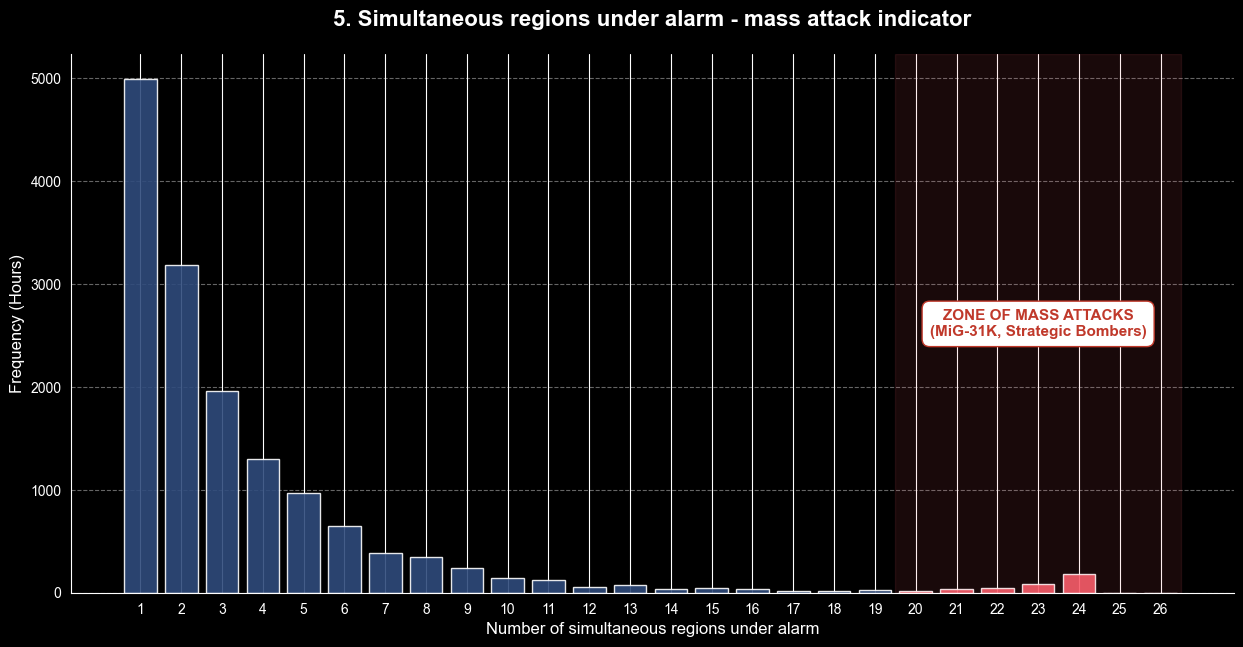

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import os
simultaneous = df_clean.groupby(['date', 'hour'])['region'].nunique().reset_index(name='n_regions')

median_regions = simultaneous['n_regions'].median()
mass_attacks = simultaneous[simultaneous['n_regions'] >= 20].shape[0]
total_hours = simultaneous.shape[0]
pct_mass = round((mass_attacks / total_hours) * 100, 1)

print(f"Median: {int(median_regions)} regions.")
print(f"20+ regions: {pct_mass}% of all active hours.")
dist = simultaneous['n_regions'].value_counts().sort_index()
all_regions = pd.Series(0, index=range(1, 27))
dist = all_regions.add(dist, fill_value=0)
plt.figure(figsize=(15, 7))
colors = ['#f95d6a' if x >= 20 else '#2f4b7c' for x in dist.index]
bars = plt.bar(dist.index, dist.values, color=colors, width=0.8, alpha=0.9, edgecolor='white')
plt.axvspan(19.5, 26.5, color='#f95d6a', alpha=0.1)
plt.text(23, dist.values.max() * 0.5, 'ZONE OF MASS ATTACKS\n(MiG-31K, Strategic Bombers)',
         color='#c0392b', fontweight='bold', ha='center', fontsize=11,
         bbox=dict(facecolor='white', edgecolor='#c0392b', boxstyle='round,pad=0.5'))
plt.title('5. Simultaneous regions under alarm - mass attack indicator',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of simultaneous regions under alarm', fontsize=12)
plt.ylabel('Frequency (Hours)', fontsize=12)
plt.xticks(range(1, 27))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
os.makedirs('plots/alarms', exist_ok=True)
plt.savefig('plots/alarms/A5_simultaneous.png', dpi=300, bbox_inches='tight')
plt.show()

Перевірялася гіпотеза про те, що масштаб ворожих атак має однорідний розподіл (імовірність залучення більшої кількості регіонів монотонно спадає). Наявність аномальних сплесків на правому краю графіка свідчитиме про існування окремого тактичного режиму - скоординованих загальнонаціональних ударів.
Аналіз:
Візуалізація розподілу одночасних тривог спростовує гіпотезу. Я спостерігаю яскраво виражений розподіл із важким правим хвостом, який відображає два паралельні формати ведення війни:

1) Тактичний рівень (локальні загрози): Більшість подій зосереджена в крайній лівій частині графіка Median 2 regions. У половині всіх випадків тривога локалізована лише в 1-2 областях. Це відображає щоденну прифронтову ситуацію (удари КАБ, артилерія, робота ворожої тактичної авіації).
2) Стратегічний рівень: У правій частині графіка формується наступне. Події, коли одночасно активні 20 і більше регіонів, класифікуються як mass attack і складають 2.4% of all active hours. Незважаючи на малу частку часу, це фізично відповідає наймасштабнішим загрозам - злетам носіїв ʼКинджалʼ або комплексним ракетним ударам стратегічної авіації.

Я розбила тривоги на 4 категорії: Швидкі (<45 хв), Середні (45хв-2год), Довгі (2-4 год) та Виснажливі (>4 год). Буде показано, яка ймовірність отримати багатогодинну тривогу залежно від того, о котрій вона почалася.
Гіпотеза передбачає, що в нічні години ймовірність виникнення багатогодинних тривог різко зростає порівняно з денним часом.

/var/folders/n2/f3yfs41x57x44f6254hp51fc0000gn/T/ipykernel_2821/112710997.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(-0.5, 5.5, color='none', edgecolor='#2c3e50', linewidth=3, linestyle='--', zorder=5)
/var/folders/n2/f3yfs41x57x44f6254hp51fc0000gn/T/ipykernel_2821/112710997.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(21.5, 23.5, color='none', edgecolor='#2c3e50', linewidth=3, linestyle='--', zorder=5)


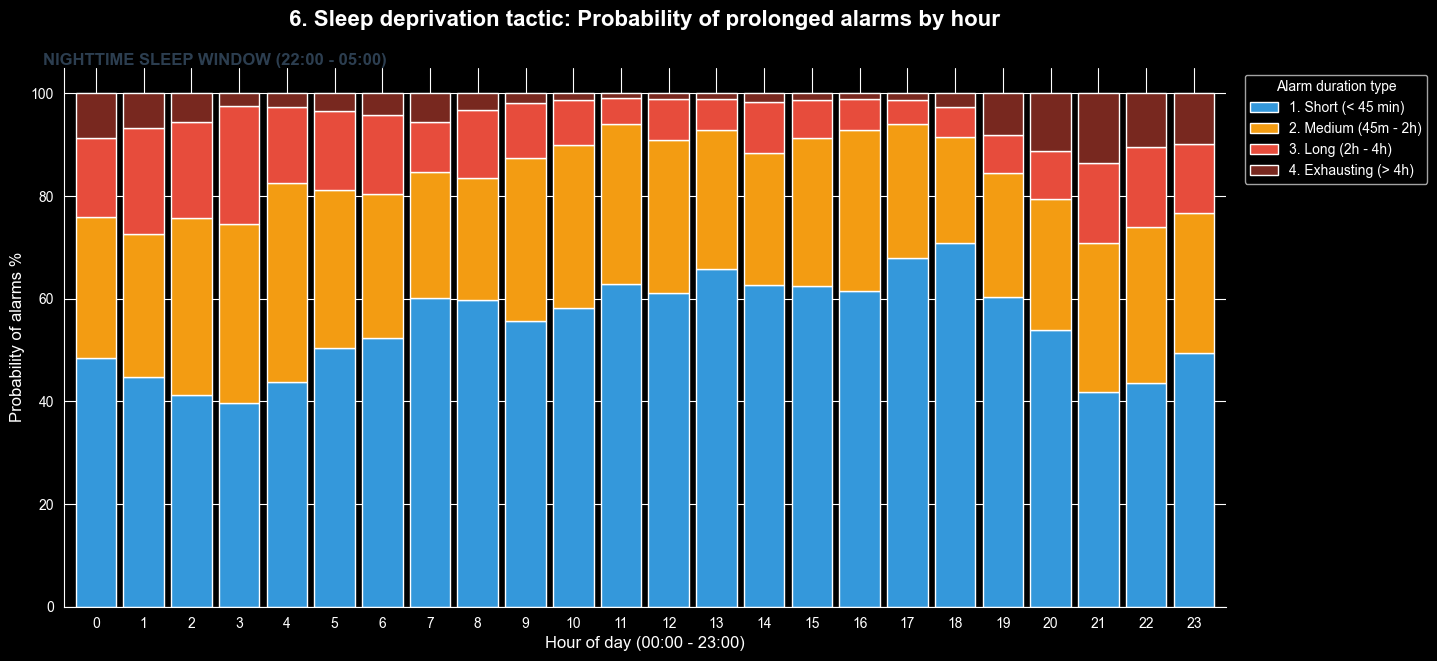

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import os

bins = [0, 45, 120, 240, 5000]
labels = ['1. Short (< 45 min)', '2. Medium (45m - 2h)', '3. Long (2h - 4h)', '4. Exhausting (> 4h)']
df_clean['duration_category'] = pd.cut(df_clean['duration_min'], bins=bins, labels=labels)

prob_matrix = pd.crosstab(df_clean['hour'], df_clean['duration_category'], normalize='index') * 100
colors = ['#3498db', '#f39c12', '#e74c3c', '#78281f']
ax = prob_matrix.plot(kind='bar', stacked=True, figsize=(15, 7), color=colors, width=0.85, edgecolor='white')
plt.axvspan(-0.5, 5.5, color='none', edgecolor='#2c3e50', linewidth=3, linestyle='--', zorder=5)
plt.axvspan(21.5, 23.5, color='none', edgecolor='#2c3e50', linewidth=3, linestyle='--', zorder=5)
plt.text(2.5, 105, 'NIGHTTIME SLEEP WINDOW (22:00 - 05:00)',
         ha='center', va='bottom', fontweight='bold', color='#2c3e50', fontsize=12)
plt.title('6. Sleep deprivation tactic: Probability of prolonged alarms by hour',
          fontsize=16, fontweight='bold', pad=30)
plt.xlabel('Hour of day (00:00 - 23:00)', fontsize=12)
plt.ylabel('Probability of alarms %', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Alarm duration type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

os.makedirs('plots/alarms', exist_ok=True)
plt.savefig('plots/alarms/A6_sleep_deprivation_stacked.png', dpi=300, bbox_inches='tight')
plt.show()

1. Денна тактика (08:00 - 19:00): У денний час домінують синій (Short < 45 min) та помаранчевий (Medium 45m - 2h) сегменти. Ймовірність того, що тривога закінчиться швидко, складає близько 70-80%. Це класичний профіль швидкісних загроз: балістика, злети МіГ-31К або робота тактичної авіації біля фронту.
2. Нічна тактика виснаження (22:00 - 05:00): У межах вікна сну структура ламається. Синій сегмент швидких тривог звужується (падає до мінімуму о 01:00-02:00). Натомість зелений (Long 2h - 4h) та червоний (Exhausting > 4h) сегменти розширюються в рази. Якщо тривога починається о 2-й ночі, ймовірність того, що люди просидять в укритті понад 2 години, наближається до 45-50%. Це прямий наслідок запуску БПЛА.
3. Перехідна фаза (19:00 - 21:00): На графіку видно злам у вечірні години: зелений та червоний сегменти починають плавно зростати. Це час фактичного запуску вечірніх груп дронів, які якраз починають входити в повітряний простір України.